In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

In [ ]:
def k_fold_cv(X, y, k=5, n_neighbors=3):
    fold_size = len(X) // k
    accuracies = []

    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size

        X_test = X[start:end]
        y_test = y[start:end]

        X_train = np.vstack((X[:start], X[end:]))
        y_train = np.hstack((y[:start], y[end:]))

        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))

    return np.mean(accuracies)

In [ ]:
avg_accuracy = k_fold_cv(X, y, k=5)
print(f"Average k-NN accuracy (k-Fold CV): {avg_accuracy:.3f}")

Average k-NN accuracy (k-Fold CV): 0.907


In [ ]:
def bootstrap_regression(X, y, n_bootstraps=500):
    n = len(X)
    coefficients = []

    for _ in range(n_bootstraps):
        indices = np.random.choice(n, n, replace=True)
        X_boot = X[indices]
        y_boot = y[indices]

        model = LinearRegression()
        model.fit(X_boot, y_boot)
        coefficients.append(model.coef_)

    return np.array(coefficients)

In [ ]:
X_reg = X[:, :2]
y_reg = X[:, 2]

coefs = bootstrap_regression(X_reg, y_reg)


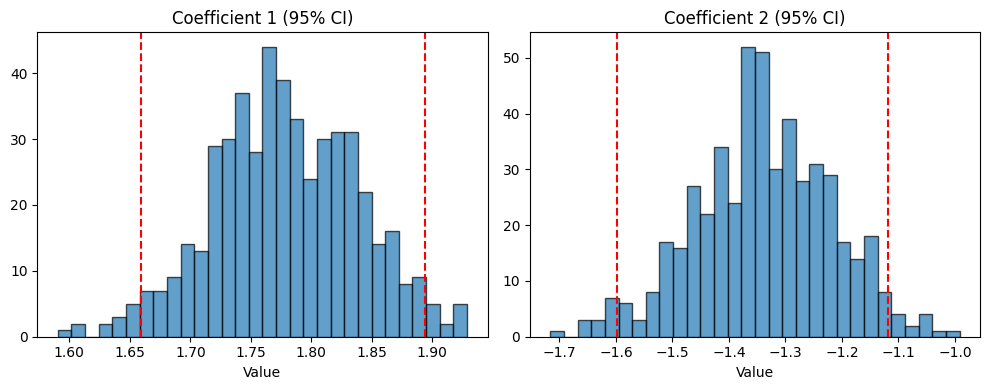

In [ ]:
plt.figure(figsize=(10, 4))

# Coefficient 1
plt.subplot(1, 2, 1)
plt.hist(coefs[:, 0], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.percentile(coefs[:, 0], 2.5), color='red', linestyle='--')
plt.axvline(np.percentile(coefs[:, 0], 97.5), color='red', linestyle='--')
plt.title("Coefficient 1 (95% CI)")
plt.xlabel("Value")

# Coefficient 2
plt.subplot(1, 2, 2)
plt.hist(coefs[:, 1], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(np.percentile(coefs[:, 1], 2.5), color='red', linestyle='--')
plt.axvline(np.percentile(coefs[:, 1], 97.5), color='red', linestyle='--')
plt.title("Coefficient 2 (95% CI)")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

In [ ]:
print("\nBootstrap Results (95% Confidence Intervals):")
for i in range(coefs.shape[1]):
    lower = np.percentile(coefs[:, i], 2.5)
    upper = np.percentile(coefs[:, i], 97.5)
    print(f"Coefficient {i+1}: [{lower:.3f}, {upper:.3f}]")


Bootstrap Results (95% Confidence Intervals):
Coefficient 1: [1.659, 1.894]
Coefficient 2: [-1.598, -1.119]
